<a href="https://colab.research.google.com/github/amigli/Q-Bert_RL/blob/main/Notebook/temp/TestQLearning_Debugging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training e Test con Q-Learning
In questo notebook è presente il training di Q*Bert sfruttando l'algoritmo Q-Learning


## Download Repository

Download della repository per utilizzare le classi create su Google Colab

In [1]:
from google.colab import userdata

In [16]:
! git clone https://{userdata.get('TokenGithub')}"@github.com/amigli/Q-Bert_RL.git"

Cloning into 'Q-Bert_RL'...
remote: Enumerating objects: 242, done.
remote: Counting objects: 100% (242/242), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 242 (delta 134), reused 144 (delta 63), pack-reused 0 (from 0)
Receiving objects: 100% (242/242), 1.35 MiB | 4.54 MiB/s, done.
Resolving deltas: 100% (134/134), done.


In [17]:
%cd Q-Bert_RL

/content/Q-Bert_RL


In [10]:
!git rev-parse HEAD


c2863a21beb20df88808461b87eba845ce640d39


## Installazione dei requirements

Vengono installati tutti i moduli necessari dal file requirements.txt

In [3]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 11.6 MB/s eta 0:00:00


In [4]:
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.1 MB/s eta 0:00:00


In [6]:
!pip install moviepy

## Training

In [93]:
class RewardFunction():
    def __init__(self, init_lives):
        self.lives = init_lives

    def calculate_reward(self, observation, reward):
        calculated_reward =  0
        # print("Reward ambiente:" + str(reward))
        match reward:
            case 25:
                calculated_reward = 2
            case 100:
                calculated_reward = 2.5
            case 300:
                calculated_reward = 3
            case 500:
                calculated_reward = 3.5
            case 3100:
                calculated_reward = 5
            case _:
                if reward > 0:
                    calculated_reward = 3.5 # Bonus che QBert può ricevere in alcuni round
                else:
                    calculated_reward = 0

        next_lives, obs =  observation[0], observation[1]
        match next_lives:
          case 2:
            next_lives = 4
          case 1:
            next_lives = 3
          case 0:
            next_lives =  2
          case 255:
            next_lives = 1
          case 254:
            next_lives = 0

        # print("next_lives:" + str(next_lives) + ", old_lives:" + str(self.lives))
        if next_lives < self.lives :
            calculated_reward = 0 - 1
            self.lives = next_lives
            # print("Morto")

        if obs[0] != None:
            if obs[24] != None and obs[24].xy == obs[0].xy:
                print("Scontro con avversario 1")
                calculated_reward = 0 - 2
            if obs[25] != None and obs[25].xy == obs[0].xy:
                print("Scontro con avversario 1")
                calculated_reward = 0 - 2

        """if calculated_reward == 0:
            # QBert non ha fatto nulla, si dà una piccola penalità per evitare che stia fermo ad aspettare (esegue NO_OP)
            calculated_reward = 0- 0.5"""
        # print(calculated_reward)
        return calculated_reward

In [94]:
import gymnasium as gym
from OC_Atari_Files.qbert import _detect_objects_ram, _init_objects_ram
import numpy as np


class ObsRewardWrapper(gym.Wrapper):
    def __init__(self, env):
        super(ObsRewardWrapper, self).__init__(env)
        self.reward_function = RewardFunction(init_lives=4)
        self.observation_space = gym.spaces.Box(
            low=-np.inf, high=np.inf, shape=(75,), dtype=np.float32
        )

    def reset(self, **kwargs):
        # Richiama il reset originale
        observation, info = self.env.reset(**kwargs)
        self.reward_function = RewardFunction(init_lives=4)
        obs = _init_objects_ram()
        obs = _detect_objects_ram(obs, observation, hud=False)
        newobs = []

        if obs[0] != None:
            # Inserimento delle coordinate del giocatore
            newobs.append(obs[0].xy[0])
            newobs.append(obs[0].xy[1])

            # Inserimento dei colori dei cubi:
            for i in range(21):
                j = i+1
                if obs[j] != None:
                    newobs.append(obs[j].rgb[0])
                    newobs.append(obs[j].rgb[1])
                    newobs.append(obs[j].rgb[2])
                else:
                    newobs.append(0)
                    newobs.append(0)
                    newobs.append(0)

            # Inserimento delle posizioni dei dischi di salvataggio
            if obs[23] != None :
                # Inserimento delle posizioni dei dischi di salvataggio
                newobs.append(obs[23].xy[0])
                newobs.append(obs[23].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[24] != None :
                # Inserimento delle coordinate di coily
                newobs.append(obs[24].xy[0])
                newobs.append(obs[24].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[25] != None :
                # Inserimento delle coordinate di Purple Ball
                newobs.append(obs[25].xy[0])
                newobs.append(obs[25].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[26] != None :
                # Inserimento delle coordinate di Purple Ball
                newobs.append(obs[26].xy[0])
                newobs.append(obs[26].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[26] != None :
                # Inserimento delle coordinate di Sam
                newobs.append(obs[27].xy[0])
                newobs.append(obs[27].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            newobs = np.array(newobs)
        else:
            newobs =  np.zeros(75)

        return newobs, info


    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)
        obs = _init_objects_ram()
        obs = _detect_objects_ram(obs, observation, hud=False)
        newobs = []

        if obs[0] != None:
            # Inserimento delle coordinate del giocatore
            newobs.append(obs[0].xy[0])
            newobs.append(obs[0].xy[1])

            # Inserimento dei colori dei cubi:
            for i in range(21):
                j = i+1
                if obs[j] != None:
                    newobs.append(obs[j].rgb[0])
                    newobs.append(obs[j].rgb[1])
                    newobs.append(obs[j].rgb[2])
                else:
                    newobs.append(0)
                    newobs.append(0)
                    newobs.append(0)

            # Inserimento delle posizioni dei dischi di salvataggio
            if obs[23] != None :
                # Inserimento delle posizioni dei dischi di salvataggio
                newobs.append(obs[23].xy[0])
                newobs.append(obs[23].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[24] != None :
                # Inserimento delle coordinate di coily
                newobs.append(obs[24].xy[0])
                newobs.append(obs[24].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[25] != None :
                # Inserimento delle coordinate di Purple Ball
                newobs.append(obs[25].xy[0])
                newobs.append(obs[25].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[26] != None :
                # Inserimento delle coordinate di Purple Ball
                newobs.append(obs[26].xy[0])
                newobs.append(obs[26].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            if obs[26] != None :
                # Inserimento delle coordinate di Sam
                newobs.append(obs[27].xy[0])
                newobs.append(obs[27].xy[1])
            else:
                newobs.append(0)
                newobs.append(0)

            newobs = np.array(newobs)
        else:
            newobs =  np.zeros(75)
        obs = (observation[8], obs, newobs)
        reward = self.reward_function.calculate_reward(obs, reward)

        return newobs, reward, terminated, truncated, info

In [95]:
from Algorithms.QBertAgent_QLearning import QBAgent
import gymnasium as gym
import ale_py
from tqdm.notebook import tqdm
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

gym.register_envs(ale_py)

# hyperparameters
learning_rate = 0.01
n_episodes = 20000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

## TRAINING
env = gym.make("ALE/Qbert-ram-v5")
env =  ObsRewardWrapper(env)
env = RecordEpisodeStatistics(env, buffer_length=n_episodes)


agent = QBAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

# history = []
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    # print("Episode:" + str(episode))
    total_reward = 0
    while not done:
        action = agent.get_action(obs, True)
        # print(action)
        next_obs, reward, terminated, truncated, info = env.step(action)
        next_obs = tuple(next_obs)
        # print("Reward: " + str(reward))
        # print("action: " + str(action))

        total_reward += reward
        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()
    # print(total_reward)

env.close()

  0%|          | 0/20000 [00:00<?, ?it/s]

Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1
Scontro con avversario 1


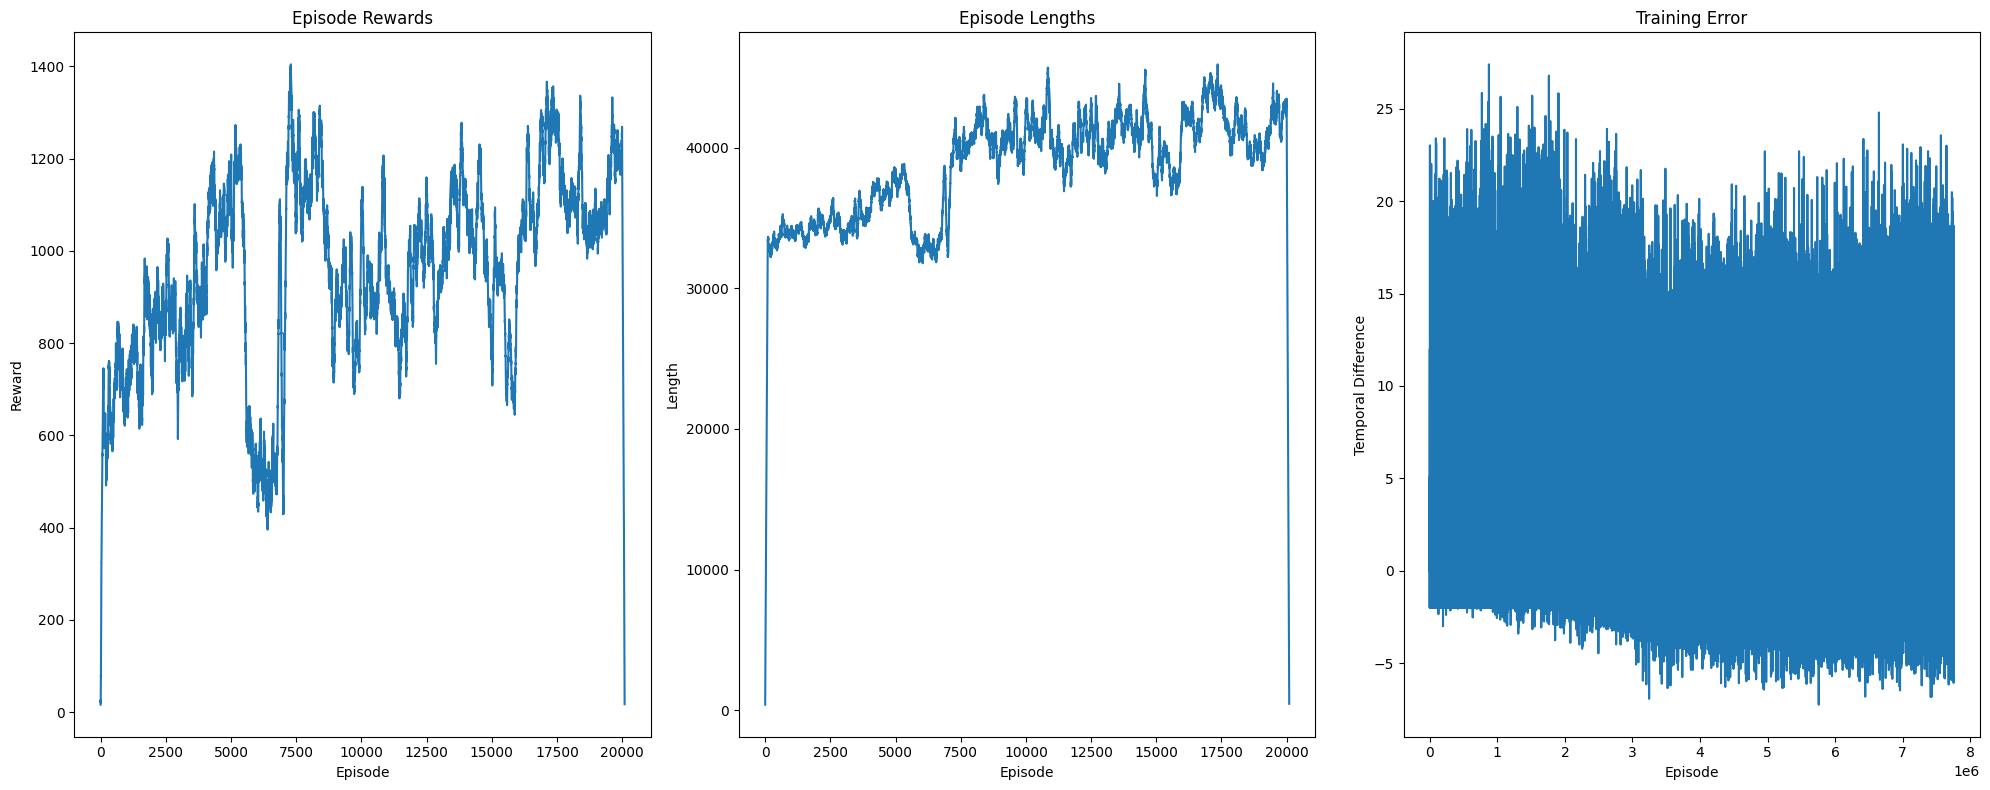

In [96]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

# Utilizzo Policy

Di seguito viente utilizzata la policy precedentemente calcolata per registrare degli episodi

In [97]:
num_eval_episodes = 10

env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")
env =  ObsRewardWrapper(env)
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=num_eval_episodes)


for episode_num in range(num_eval_episodes):
    #print(f"Stato osservato: {obs}")  # Debug per lo stato osservato
    #print(f"Valori Q per lo stato {obs}: {agent.q_values[obs]}")  # Debug per i valori Q
    obs, info = env.reset()
    done = False
    obs = tuple(obs)
    while not done:
        action = agent.get_action(obs, False)
        next_obs, reward, terminated, truncated, info = env.step(action)
        obs = tuple(next_obs)
        done = terminated or truncated
env.close()

print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')

print("Training terminato")


Output streaming troncato alle ultime 5000 righe.
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!3
Ho scelto il meglio!3
Ho scelto il meglio!5
Ho scelto il meglio!4
Ho scelto il meglio!1
Ho scelto il meglio!1
Ho scelto il meglio!3
Ho scelto il meglio!4
Ho scelto il meglio!5
Ho scelto il meglio!1
Ho scelto il meglio!2
Ho scelto il meglio!3
Ho scelto il meglio!2
Ho scelto il meglio!3
Ho scelto il meglio!4
Ho scelto il meglio!3
Ho scelto il meglio!1
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!0
Ho scelto il meglio!2
Ho scelto il meglio!5
Ho scelto il meglio!3
Ho scelto il meglio!3
Ho scelto il meglio!3
Ho scelto il meglio!2
Ho s

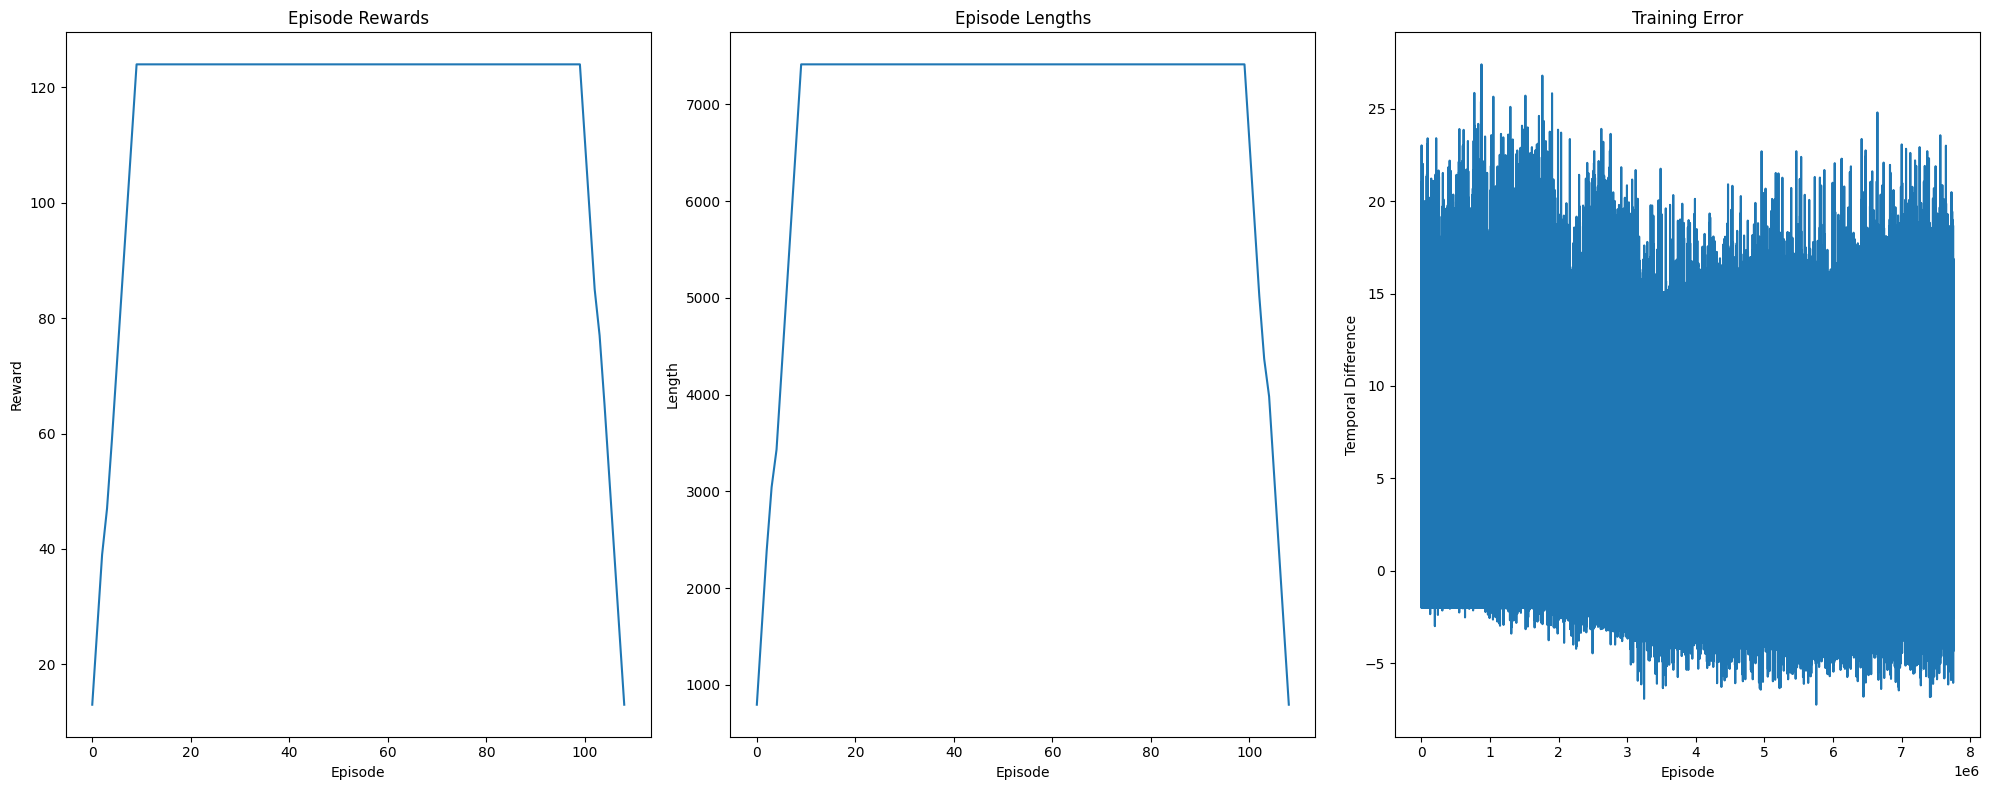

In [98]:
from matplotlib import pyplot as plt
import numpy as np

# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()